# Mateix codi però amb els valors de les constants de l'article de Moncho

# Modes d'Alfvén

vAp2, vAc2 3978873577.297384 795774715459.4768
Valors normalitzats a vAp2
vAp2, vAc2 1.0 200.0
2025-06-14 17:20:50,182 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 28s, Remaining: 0s, Rate: 3.6e-02/s
evals.size (before)  258
evals.size (after removing inf)  254
evals.size (after removing < 0)  246

evals size 246
true_evals size  246
First 5 Eigenvalues (sqrt): [ 0.52495052 45.95787265 47.19530204 94.46560155 94.88704399]
First 5 True eigenvalues: [ 3.25020007 16.13536719 31.10953036 44.80108015 49.13846219]
Relative error (resta norm.): [0.83848671 1.8482694  0.51706893 1.10855634 0.93101371]


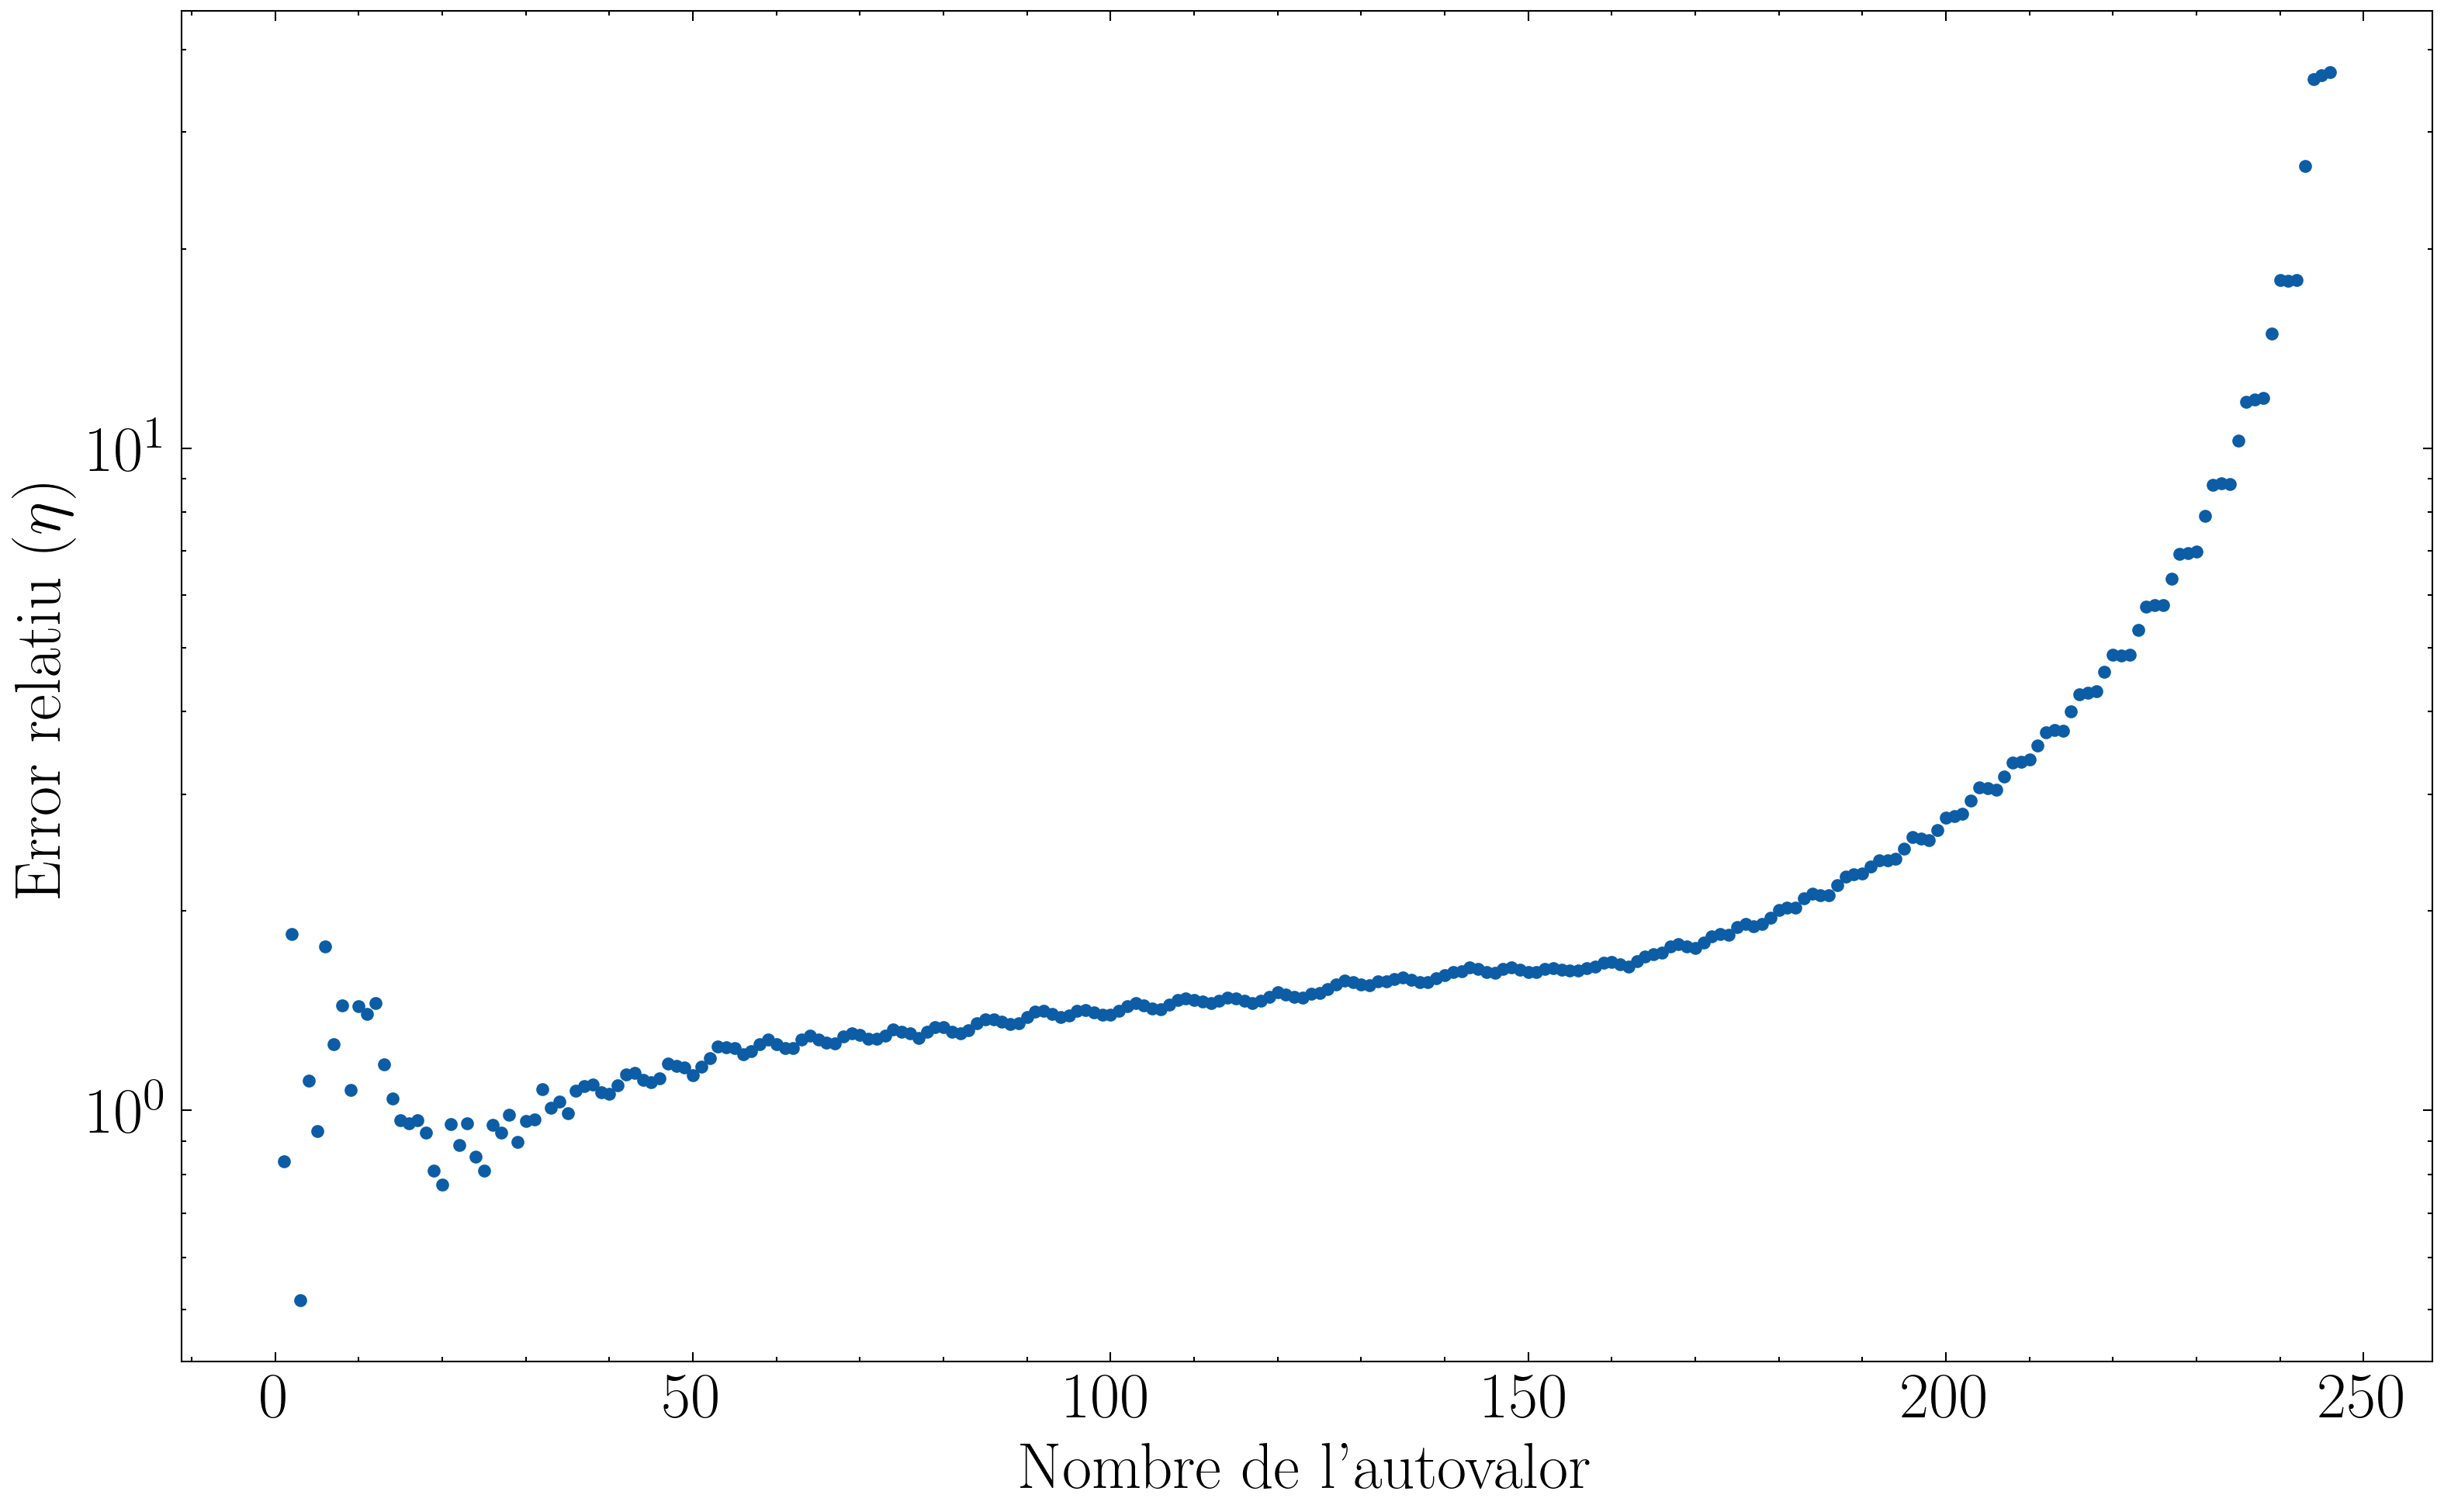

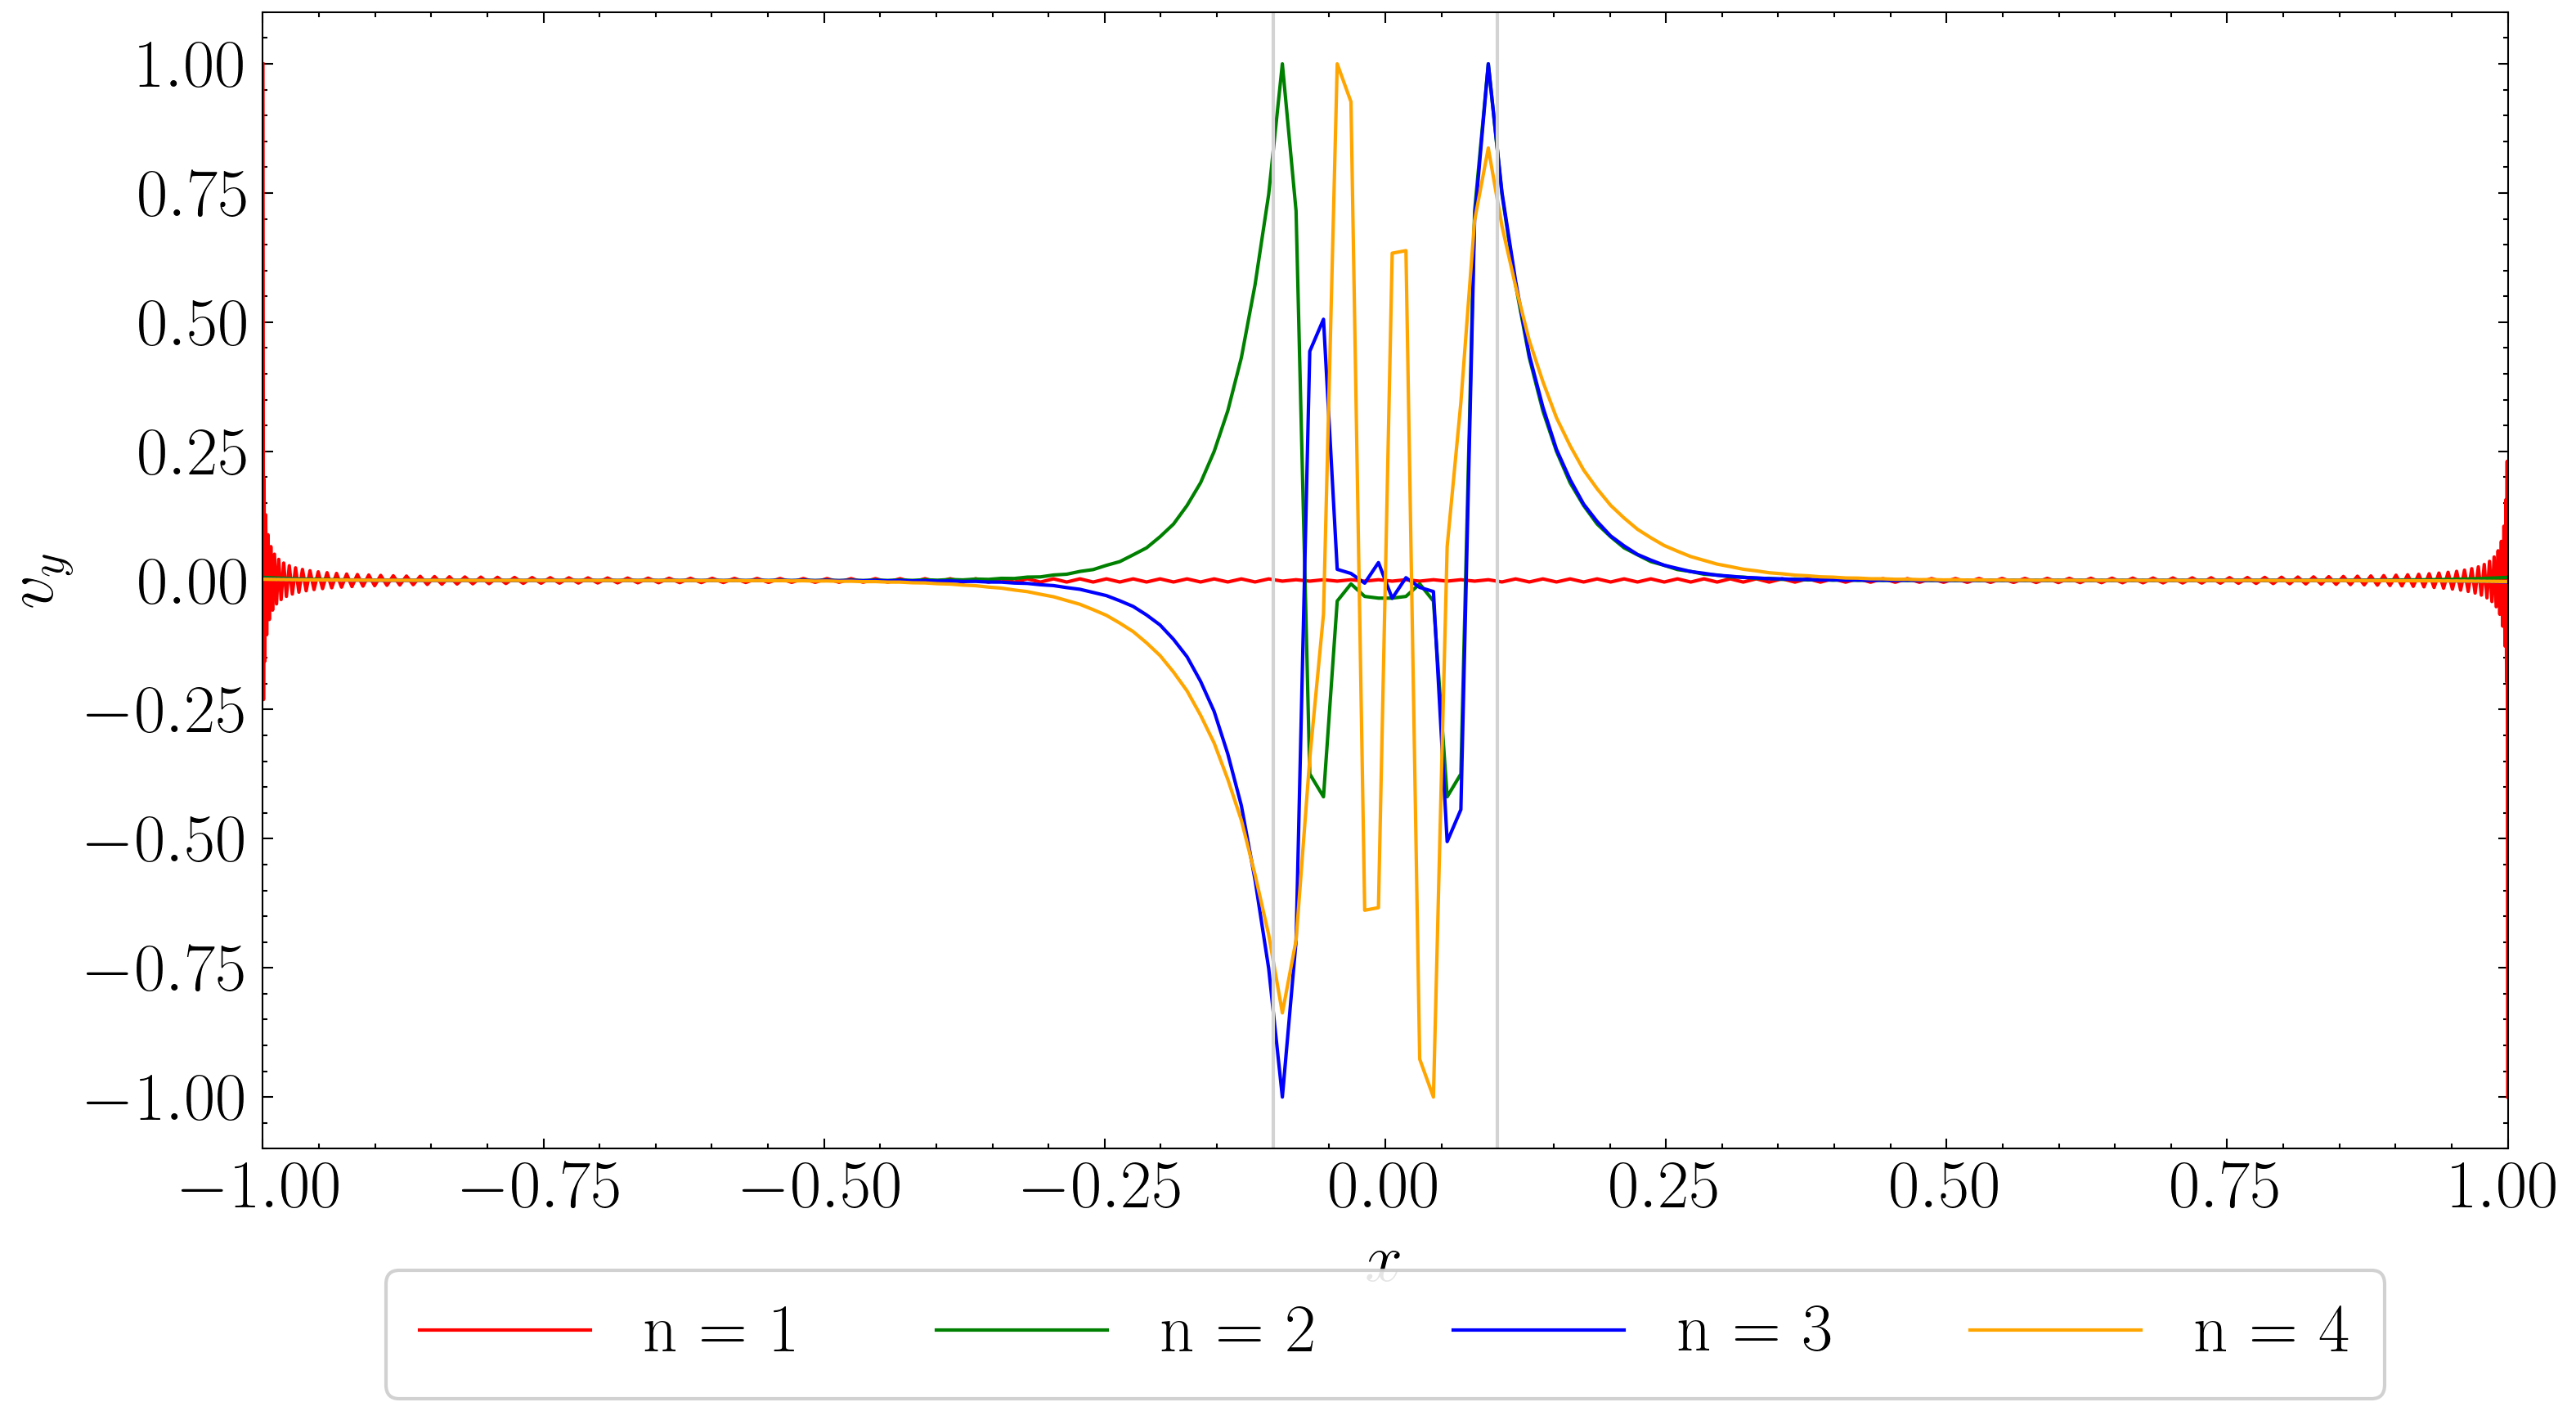

' Plot imag part of v10y\nplt.figure(figsize=(10, 6))\nx = dist.local_grid(xbasis)\n##print("Eigenvalues whose eigenfunctions are plotted, real and imaginary parts")\nfor n, idx in enumerate(np.argsort(solver.eigenvalues)[:4], start=1):\n    solver.set_state(idx, solver.subsystems[0])\n    ##if solver.eigenvalues[idx].real > 0:\n    ##    print(f"{idx:04d}    {solver.eigenvalues[idx].real:+.2e}    {solver.eigenvalues[idx].imag:+.2e}")\n\n    # ens interessa part Im per comprovar que està bé; ha de ser nul·la\n    vg = (v[\'g\'] / v[\'g\'][1]).real\n    vi = (v[\'g\'] / v[\'g\'][1]).imag\n    plt.plot(x, vi/np.max(np.abs(vg)), label=f"n={n}") # no normalitzam pq ens divideix per 0 ### ara sí normalitzam\nplt.xlim(xmin, xmax)\nplt.legend(loc="lower right", frameon=True)\nplt.ylabel(r"Mode structure")\nplt.xlabel(r"x")\nplt.title(r"Imaginary part of $v_{y}$")\nplt.tight_layout()\n#plt.savefig("Im_A_eigenvectors.pdf")\n#plt.savefig("Im_A_eigenvectors.png", dpi=200)\n'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import dedalus.public as d3
from scipy.optimize import fsolve
import scienceplots
plt.style.use('science')
plt.rcParams.update({
    "font.size": 20,           # Match LaTeX body text (12pt)
    #"font.weight": "bold",     # Match LaTeX body text (bold)
    "axes.titlesize": 20,      # Title font size
    "axes.labelsize": 20,      # Axis label font size
    #"axes.labelweight": "bold",# Axis label weight
    "xtick.labelsize": 20,     # X tick label font size
    "ytick.labelsize": 20,     # Y tick label font size
    "legend.fontsize": 20,     # Legend font size
    "figure.dpi": 300,         # High DPI for sharpness
    #"font.family": "serif",    # Optional: match LaTeX font
    "mathtext.fontset": "cm",  # Optional: Computer Modern math
    "text.usetex": True,                # Use LaTeX for all text
    #"font.serif": ["Computer Modern"],  # Use Computer Modern (LaTeX default)
})



""" Funcions per calcular els autovalors exactes """
# Funcions den Monxo per calcular els autovalors exactes d'una corda amb densitat variable.
def dispersion_relation(omega):
    disprel_even = (np.sqrt(vAp2)/np.sqrt(vAc2)) * np.cos(omega * (xmax - xp) / np.sqrt(vAc2)) * np.cos(omega * xp / np.sqrt(vAp2)) - \
        np.sin(omega * (xmax - xp) / np.sqrt(vAc2)) * np.sin(omega * xp / np.sqrt(vAp2))
    disprel_odd = (np.sqrt(vAp2)/np.sqrt(vAc2)) * np.cos(omega * (xmax - xp) / np.sqrt(vAc2)) * np.sin(omega * xp / np.sqrt(vAp2)) + \
        np.sin(omega * (xmax - xp) / np.sqrt(vAc2)) * np.cos(omega * xp / np.sqrt(vAp2))
    disprel = disprel_even * disprel_odd
    return disprel

def get_eigenvalues(Nevals):
    Nsol = 0
    omega0 = 1
    omega_step = 0.5
    exact_soln = np.array([])
    while Nsol < Nevals:
        sol = fsolve(dispersion_relation, omega0)
#         print('omega0, sol ', omega0, sol)
        if sol > 0:
            exact_soln = np.append(exact_soln, sol)
            exact_soln = np.unique(exact_soln.round(decimals=8))
#         print('exact_soln, exact_soln**2 ', exact_soln, exact_soln**2)
#         print(exact_soln.size)
        Nsol = exact_soln.size
        omega0 = omega0 + omega_step
#    print('exact_soln', exact_soln[0:5])
#    print('exact_soln**2 ', exact_soln**2)
    print()
    return exact_soln



""" Paràmetres """
Nx = 128*2 # amb 32 ja no és smooth...
dtype = np.complex128 # malla en la que es treballa: 128 complexes, ja que hem definit Nx = 128



""" Límits del domini """
xmax = 1
xmin = -1 # = -xmax
xp = 0.1
# xc ∈ [-1, -0.1], xc ∈ [0.1, 1]

# Square of the wave velocity in the two parts of the system.
vAp2 = 3978873577.297384 # 20
vAc2 = 795774715459.4768 # 250
print("vAp2, vAc2", vAp2, vAc2)

vAc2 /= vAp2
vAp2 /= vAp2
print("Valors normalitzats a vAp2")
print("vAp2, vAc2", vAp2, vAc2)



""" Bases """
xcoord = d3.Coordinate('x')
dist = d3.Distributor(xcoord, dtype=dtype)
xbasis = d3.Legendre(xcoord, size=Nx, bounds=(xmin, xmax)) # Definim una base amb uns altres límits. Chebyshev menos error?



""" Camps """
### Velocitats ###
v = dist.Field(name='v', bases=xbasis) # v = field of the wave function: v10y
# Definesc la velocitat com en oceano: (u,v,w) per no liar subíndexos i derivades.

### Espai real ###
x = dist.local_grid(xbasis) # punts del domini

### Constants ###
vA2 = dist.Field(name='vA2', bases=xbasis) # vA2 = Alfven velocity squared ----- és interessant definir-la directament al quadrat ja que és un camp i així evitam fer c.evaluate()**2
vA2['g'] = np.piecewise(x, [x < -xp, (-xp <= x) * (x <= xp), x > xp], [vAc2, vAp2, vAc2]) # Representa la velocitat d'Alfven en l'espai real ('g') a trossos.
kz = dist.Field(name='kz', bases=xbasis) # kz = Wave number in the z direction
#kz['g'] = 0 # Representa el nombre d'ona en la direcció z en l'espai real ('g').
kz['g'] = np.piecewise(x, [x < -xp, (-xp <= x) * (x <= xp), x > xp], [0, 0, 0]) # Representa el nombre d'ona en la direcció z en l'espai real ('g') a trossos.

### Autovalors ###
s = dist.Field(name='s') # AUTOVALOR ω^2 = s

### Auxiliars de les derivades ###
tau_1 = dist.Field(name='tau_1')
tau_2 = dist.Field(name='tau_2')



""" Substitucions """
### Derivades espacials ###
dx = lambda A: d3.Differentiate(A, xcoord) # Derivative operator
lift_basis = xbasis.derivative_basis(1)
lift = lambda A: d3.Lift(A, lift_basis, -1)
vx = dx(v) + lift(tau_1) # First-order reduction of the velocity in the y direction
vxx = dx(vx) + lift(tau_2) # Second-order reduction of the velocity in the y direction
# No és convenient posar directament dx(v) a l'equació ja que faltaria el lift... s'ha de definir bé la derivada
# No definim derivada temporal ja que és un EVP!!!



""" Problem """
# 1 equació i 1 incògnita
problem = d3.EVP([v, tau_1, tau_2], eigenvalue=s, namespace=locals())

# Problema d'ones d'Alfvén ~ corda guitarra amb densitat variable
problem.add_equation("s * v  +  vA2 * vxx  =  0") # (18')
problem.add_equation("v(x=xmin) = 0")
problem.add_equation("v(x=xmax) = 0")



""" Solve """
solver = problem.build_solver()
# print(solver.subproblems)
solver.solve_dense(solver.subproblems[0])
evals = np.sort(solver.eigenvalues)

print('evals.size (before) ', evals.size)
evals = evals[~np.isinf(evals)]                      # eliminam els infinits; el ~ és un operador bitwise NOT, que retorna True si el valor és False i viceversa
print('evals.size (after removing inf) ', evals.size)
evals = evals[evals > 0]                             # eliminam els valors negatius
print('evals.size (after removing < 0) ', evals.size)
evals = np.sqrt(evals)

# Autovalors exactes
Nevals = np.rint(Nx*1.2).astype(int)
exact_soln = get_eigenvalues(Nevals)
n = 1 + np.arange(evals.size)
# true_evals = (n * np.pi / 2*xmax)**2               # vàlid per vA2 constant
true_evals = exact_soln[0:evals.size]

print('evals size', evals.size)
#print("Evals", evals)
print("true_evals size ", true_evals.size)
#print("True Evals", true_evals)

relative_error = np.abs(evals - true_evals) / true_evals

# Agafam la part real per fer un print més net
evals = evals.real
print("First 5 Eigenvalues (sqrt):", evals[:5])
print("First 5 True eigenvalues:", true_evals[:5])
print("Relative error (resta norm.):", relative_error[:5])



""" Plot """
### Plot error ###
plt.figure(figsize=(11, 7))
plt.semilogy(n, relative_error, '.')
plt.xlabel("Nombre de l'autovalor")
plt.ylabel(fr"Error relatiu $(\eta)$")
#plt.title("Eigenvalue error")
plt.tight_layout()
plt.savefig("eigenvalue_error_vA_apendix.png", dpi=300, bbox_inches='tight')
plt.show()


### Define colors for the lines ###
colors = ['red', 'green', 'blue', 'orange', 'purple', 'brown', 'pink', 'gray']

### Define mode labels ###
mode_labels = [
    r"n = 1",
    r"n = 2",
    r"n = 3",
    r"n = 4",
    r"n = 5",
    r"n = 6",
    r"n = 7",
]

### Eigenvalues to plot ###
N_min_modes = 0
N_max_modes = 4

### Plot real part of v10y ###
plt.figure(figsize=(11, 7))
x = dist.local_grid(xbasis)
lines = []
labels = []
##print("Eigenvalues whose eigenfunctions are plotted, real and imaginary parts")
for n, idx in enumerate(np.argsort(solver.eigenvalues)[N_min_modes:N_max_modes], start=1):
   ##if solver.eigenvalues[idx].real > 0:
   ##     print(f"{idx:04d}    {solver.eigenvalues[idx].real:+.2e}    {solver.eigenvalues[idx].imag:+.2e}")

   solver.set_state(idx, solver.subsystems[0])
   vg = (v['g']).real / (v['g'][1]).real
   label = f"{mode_labels[n-1]}" if n-1 < len(mode_labels) else f"n = {n}"
   line, = plt.plot(x, vg/np.max(np.abs(vg)), label=label, color=colors[n-1])
   lines.append(line)
   labels.append(label)
   
plt.xlim(xmin, xmax)
plt.ylabel(r"${v}_{y}$")
plt.xlabel(r"$x$")
#plt.title(r"Part real de $v_{y}$")
yticks = np.arange(-1.0, 1.25, 0.25)
plt.yticks(yticks)
plt.axvline(x=-xp, color='lightgrey', linestyle='-', linewidth=1)
plt.axvline(x=xp, color='lightgrey', linestyle='-', linewidth=1)

plt.legend(
    handles=lines,
    labels=labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.25),# Centered, just below the x axis
    ncol=len(lines),            # One column per mode for a wide legend
    frameon=True,
    fontsize=20,
    title_fontsize=20,
    handlelength=2.5,
    handleheight=0.5,
    borderpad=0.5,
    borderaxespad=0.5,
    labelspacing=0.1,
    framealpha=0.9
)

plt.savefig("modes_Alfven_apendix.png", dpi=300, bbox_inches='tight')
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

""" Plot imag part of v10y
plt.figure(figsize=(10, 6))
x = dist.local_grid(xbasis)
##print("Eigenvalues whose eigenfunctions are plotted, real and imaginary parts")
for n, idx in enumerate(np.argsort(solver.eigenvalues)[:4], start=1):
    solver.set_state(idx, solver.subsystems[0])
    ##if solver.eigenvalues[idx].real > 0:
    ##    print(f"{idx:04d}    {solver.eigenvalues[idx].real:+.2e}    {solver.eigenvalues[idx].imag:+.2e}")

    # ens interessa part Im per comprovar que està bé; ha de ser nul·la
    vg = (v['g'] / v['g'][1]).real
    vi = (v['g'] / v['g'][1]).imag
    plt.plot(x, vi/np.max(np.abs(vg)), label=f"n={n}") # no normalitzam pq ens divideix per 0 ### ara sí normalitzam
plt.xlim(xmin, xmax)
plt.legend(loc="lower right", frameon=True)
plt.ylabel(r"Mode structure")
plt.xlabel(r"x")
plt.title(r"Imaginary part of $v_{y}$")
plt.tight_layout()
#plt.savefig("Im_A_eigenvectors.pdf")
#plt.savefig("Im_A_eigenvectors.png", dpi=200)
"""

# A l'hora de representar la part real de les autofuncions has de tenir clar que la velocitat v (v10y) és en la direcció y i és real.
# A més, el que es representa és la velocitat, no la corda en sí. Llavors un node implica velocitat nul·la: aquell punt no es mou.
# Els màxims i mínims són els punts on la velocitat és màxima absolutament, no és que la corda es deformi amb aquella forma...


# Modes ràpids i lents

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import dedalus.public as d3
from scipy.optimize import fsolve
import logging
import matplotlib.ticker as ticker
logger = logging.getLogger(__name__)
from IPython.display import display
import scienceplots
plt.style.use('science')
plt.rcParams.update({
    "font.size": 20,               # Mida general del text
    "axes.titlesize": 20,         # Mida del títol dels eixos
    "axes.labelsize": 20,         # Mida de les etiquetes dels eixos
    "xtick.labelsize": 20,        # Mida dels ticks de l'eix X
    "ytick.labelsize": 20,        # Mida dels ticks de l'eix Y
    "legend.fontsize": 20,        # Mida del text de la llegenda
    "figure.dpi": 300,            # Resolució
    "text.usetex": True,          # Activa LaTeX per al text
    "mathtext.fontset": "cm",     # (Opcional) Usa Computer Modern si no s’usa LaTeX
#    #"font.serif": ["Computer Modern"],  # Use Computer Modern (LaTeX default)
#    #"font.family": "serif",    # Optional: match LaTeX font
})

from matplotlib.lines import Line2D
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch



""" Funcions per calcular els autovalors exactes """
# Funcions den Monxo per calcular els autovalors exactes d'una corda amb densitat variable.
def dispersion_relation(omega):
    disprel_even = (np.sqrt(cp2)/np.sqrt(cc2)) * np.cos(omega * (xmax - xp) / np.sqrt(cc2)) * np.cos(omega * xp / np.sqrt(cp2)) - \
        np.sin(omega * (xmax - xp) / np.sqrt(cc2)) * np.sin(omega * xp / np.sqrt(cp2))
    disprel_odd = (np.sqrt(cp2)/np.sqrt(cc2)) * np.cos(omega * (xmax - xp) / np.sqrt(cc2)) * np.sin(omega * xp / np.sqrt(cp2)) + \
        np.sin(omega * (xmax - xp) / np.sqrt(cc2)) * np.cos(omega * xp / np.sqrt(cp2))
    disprel = disprel_even * disprel_odd
    return disprel

def dispersion_relation2(omega):
    disprel_even2 = (np.sqrt(vAp2)/np.sqrt(vAc2)) * np.cos(omega * (xmax - xp) / np.sqrt(vAc2)) * np.cos(omega * xp / np.sqrt(vAp2)) - \
        np.sin(omega * (xmax - xp) / np.sqrt(vAc2)) * np.sin(omega * xp / np.sqrt(vAp2))
    disprel_odd2 = (np.sqrt(vAp2)/np.sqrt(vAc2)) * np.cos(omega * (xmax - xp) / np.sqrt(vAc2)) * np.sin(omega * xp / np.sqrt(vAp2)) + \
        np.sin(omega * (xmax - xp) / np.sqrt(vAc2)) * np.cos(omega * xp / np.sqrt(vAp2))
    disprel2 = disprel_even2 * disprel_odd2
    return disprel2

def get_eigenvalues(Nevals):
    Nsol = 0
    omega0 = 1
    omega_step = 0.5
    exact_soln = np.array([])
    while Nsol < Nevals:
        sol = fsolve(dispersion_relation, omega0)
#         print('omega0, sol ', omega0, sol)
        sol2 = fsolve(dispersion_relation2, omega0)

        if sol > 0:
            exact_soln = np.append(exact_soln, sol)
            exact_soln = np.unique(exact_soln.round(decimals=8))
#         print('exact_soln, exact_soln**2 ', exact_soln, exact_soln**2)
#         print(exact_soln.size)
        if sol2 > 0:
            exact_soln = np.append(exact_soln, sol2)
            exact_soln = np.unique(exact_soln.round(decimals=8))

        Nsol = exact_soln.size
        omega0 = omega0 + omega_step
#    print('exact_soln ', exact_soln[0:5])
#    print('exact_soln**2 ', exact_soln**2)
    print()
    return exact_soln



""" Exact parameters """
def MHD_params(T0p, T0c, rho0p, B0, multildep, multildec):
    # Physical constants in SI units.
    kB = 1.38e-23
    mp = 1.67e-27
    capR = kB / mp
    mu = np.pi * 4e-7
    gamma = 5/3

    # Parameter values in SI units.
    #B0 = 5e-4 # encara que no surti directament a ses equacions el feim servir per fer calcular altres constants.
    #T0p = 8e3
    #multildep = 0.8
    #rho0p = 5e-11
    #T0c = 1e6
    #multildec = 0.5

    p0 = rho0p * capR * T0p / multildep
    rho0c = p0 / (capR * T0c / multildec)
    print('p0 ', p0)
    print('rho0c ', rho0c)
    rho0c = rho0p * T0p / multildep / (T0c / multildec)
    print("rho0c ", rho0c)
    # Sound and Alfvén speeds.
    csp = np.sqrt(gamma * capR * T0p / multildep)
    # csp = np.sqrt(gamma * p0 / rho0p)
    vAp = B0 / np.sqrt(mu * rho0p)
    csc = np.sqrt(gamma * capR * T0c / multildec)
    # csc = np.sqrt(gamma * p0 / rho0c)
    vAc = B0 / np.sqrt(mu * rho0c)
    return csp, csc, vAp, vAc

csp, csc, vAp, vAc = MHD_params(T0p=8e3, T0c=1e6, rho0p=5e-11, B0=5e-4, multildep=0.8, multildec=0.5)
cp2 = csp * csp # 1
cc2 = csc * csc # 6
vAp2 = vAp * vAp # 20
vAc2 = vAc * vAc # 250

print("velocitats amb unitats SI (m/s)")
print('csp, csc, vAp, vAc ', csp, csc, vAp, vAc)
print('cp2, cc2, vAp2, vAc2 ', cp2, cc2, vAp2, vAc2)

print("velocitats amb unitats SI (km/s)")
print('csp, csc, vAp, vAc ', csp/1000, csc/1000, vAp/1000, vAc/1000)
print('cp2, cc2, vAp2, vAc2 ', cp2/1000, cc2/1000, vAp2/1000, vAc2/1000)

cp2_norm = cp2  # Save the original cp2 value

cp2 /= cp2_norm
cc2 /= cp2_norm
vAp2 /= cp2_norm
vAc2 /= cp2_norm

print("Veloctiats normalitzades a cp2")
print('cp2, cc2, vAp2, vAc2 ', cp2, cc2, vAp2, vAc2)



""" Paràmetres """
Nx = 128 # Nombre de punts de la malla (128, 256, 512, 1024, 2048)
dtype = np.complex128 # malla en la que es treballa: 128 complexes, ja que hem definit Nx = 128



""" Límits del domini """
xmax = 1 # xc
xmin = -1 # = -xmax
# Position of boundaries between different parts of the system (prominence and corona).
xp = 0.1
# xc ∈ [-1, -0.1], xc ∈ [0.1, 1]



""" Constants """
kz = 0.01



""" Bases """
xcoord = d3.Coordinate('x')
dist = d3.Distributor(xcoord, dtype=dtype)
xbasis = d3.Legendre(xcoord, size=Nx, bounds=(xmin, xmax)) # Definim una base amb uns altres límits. Chebyshev menos error?



""" Camps """
### Velocitats ###
u = dist.Field(name='u', bases=xbasis) # u = field of the wave function - AUTOFUNCIÓ!!! - v10x bar, coplexa
w = dist.Field(name='w', bases=xbasis) # w = Velocity in the x direction   v10z - real
# Definesc la velocitat com en oceano: (u,v,w) per no liar subíndexos i derivades.

### Espai real ###
x = dist.local_grid(xbasis)

### Constants ###
c2 = dist.Field(name='c2', bases=xbasis) # c2 = Velocitat al quadrat ----- és interessant definir-la directament al quadrat ja que és un camp i així evitam fer c.evaluate()**2
c2['g'] = np.piecewise(x, [x < -xp, (-xp <= x) * (x <= xp), x > xp], [cc2, cp2, cc2]) # Representa la c^2 en l'espai real ('g') a trossos.
vA2 = dist.Field(name='vA2', bases=xbasis) # vA2 = Alfven velocity squared
vA2['g'] = np.piecewise(x, [x < -xp, (-xp <= x) * (x <= xp), x > xp], [vAc2, vAp2, vAc2]) # Representa la velocitat d'Alfven en l'espai real ('g') a trossos.

### Autovalors ###
s = dist.Field(name='s') # AUTOVALOR ω^2 = s

### Auxiliars de les derivades ###
tau_1 = dist.Field(name='tau_1')
tau_2 = dist.Field(name='tau_2')
tau_3 = dist.Field(name='tau_3')
tau_4 = dist.Field(name='tau_4')



""" Derivades """
### Derivades espacials ###
dx = lambda A: d3.Differentiate(A, xcoord) # Derivative operator
lift_basis = xbasis.derivative_basis(1)
lift = lambda A: d3.Lift(A, lift_basis, -1)
ux = dx(u) + lift(tau_1) # First-order reduction of the velocity in the x direction
uxx = dx(ux) + lift(tau_2) # Second-order reduction of the velocity in the x direction
wx = dx(w) + lift(tau_3) # First-order reduction of the velocity in the z direction
wxx = dx(wx) + lift(tau_4) # Second-order reduction of the velocity in the z direction



""" Problema """
### Problema d'ones ràpida i lenta ###
problem = d3.EVP([u, w, tau_1, tau_2, tau_3, tau_4], eigenvalue=s, namespace=locals()) # 2 equacions i 4 incògnites
# problem.add_equation("s * u  +  c2 * uxx  =  0") # (17') # amb kz = 0
# problem.add_equation("s * w  +  vA2 * wxx  =  0") # (19') # amb kz = 0. Hauríem d'obtenir una molt semblant a la (17') però amb la velocitat en z i la constant d'Alfvén
problem.add_equation("s * u  +  c2 * uxx  +  kz * c2 * wx  =  0") # (17')
problem.add_equation("vA2 * wxx  +  c2 * kz * ux  +  (-c2 * kz**2 - vA2 * kz**2 + s) * w  =  0") # (19')
problem.add_equation("u(x=xmin) = 0")
problem.add_equation("u(x=xmax) = 0")
problem.add_equation("w(x=xmin) = 0")
problem.add_equation("w(x=xmax) = 0")
print("Number of unknowns:", len(problem.variables))
print("Number of equations:", len(problem.equations))



""" Solver """
### Solver de Dedalus ###
solver = problem.build_solver()
#print(solver.subproblems)
solver.solve_dense(solver.subproblems[0])
evals = np.sort(solver.eigenvalues)

### Ajustament de les autofuncions ###
print('evals.size (before) ', evals.size)
#evals = evals[~np.isinf(evals)] # el ~ és un operador bitwise NOT, que retorna True si el valor és False i viceversa. En aquest cas elimina els valors infinits
print('evals.size (after removing inf) ', evals.size)
evals = evals[evals > 0] # eliminam els valors negatius
print('evals.size (after removing < 0) ', evals.size)
evals = np.sqrt(evals)

### Autovalors exactes ###
Nevals = evals.size
exact_soln = get_eigenvalues(Nevals)
n = 1 + np.arange(evals.size)
true_evals = exact_soln[0:evals.size]

### Error relatiu ###
relative_error = np.abs(evals - true_evals) / true_evals

### Autovalors ###
print('evals size', evals.size)
print("true_evals size ", true_evals.size)
#print("Evals", evals)
#print("True Evals", true_evals)

# Agafam la part real per fer un print més net
evals = evals.real
print("First 7 Eigenvalues (sqrt):", [f"{val:.5f}" for val in evals[:7]])
print("First 7 True eigenvalues:", [f"{val:.5f}" for val in true_evals[:7]])
print("Relative error:", [f"{val:.5f}" for val in relative_error[:7]])
print("kz =", kz)
print()  # This adds a blank line


p0  0.004131736526946108
rho0c  2.5e-13
rho0c  2.5e-13
velocitats amb unitats SI (m/s)
csp, csc, vAp, vAc  11735.610376039398 165966.59356521335 63078.313050504 892062.0580763856
cp2, cc2, vAp2, vAc2  137724550.89820358 27544910179.640717 3978873577.297384 795774715459.4768
velocitats amb unitats SI (km/s)
csp, csc, vAp, vAc  11.735610376039398 165.96659356521334 63.078313050504 892.0620580763856
cp2, cc2, vAp2, vAc2  137724.55089820357 27544910.179640718 3978873.577297384 795774715.4594768
Veloctiats normalitzades a cp2
cp2, cc2, vAp2, vAc2  1.0 200.0 28.890082061246225 5778.016412249245
Number of unknowns: 6
Number of equations: 6
2025-06-14 17:22:57,336 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 11s, Remaining: 0s, Rate: 9.2e-02/s
evals.size (before)  260
evals.size (after removing inf)  260
evals.size (after removing < 0)  250

evals size 250
true_evals size  250
First 7 Eigenvalues (sqrt): ['45.21856', '46.62428', '92.73823', '94.44464', '141.07913', 

# Representació de l'error

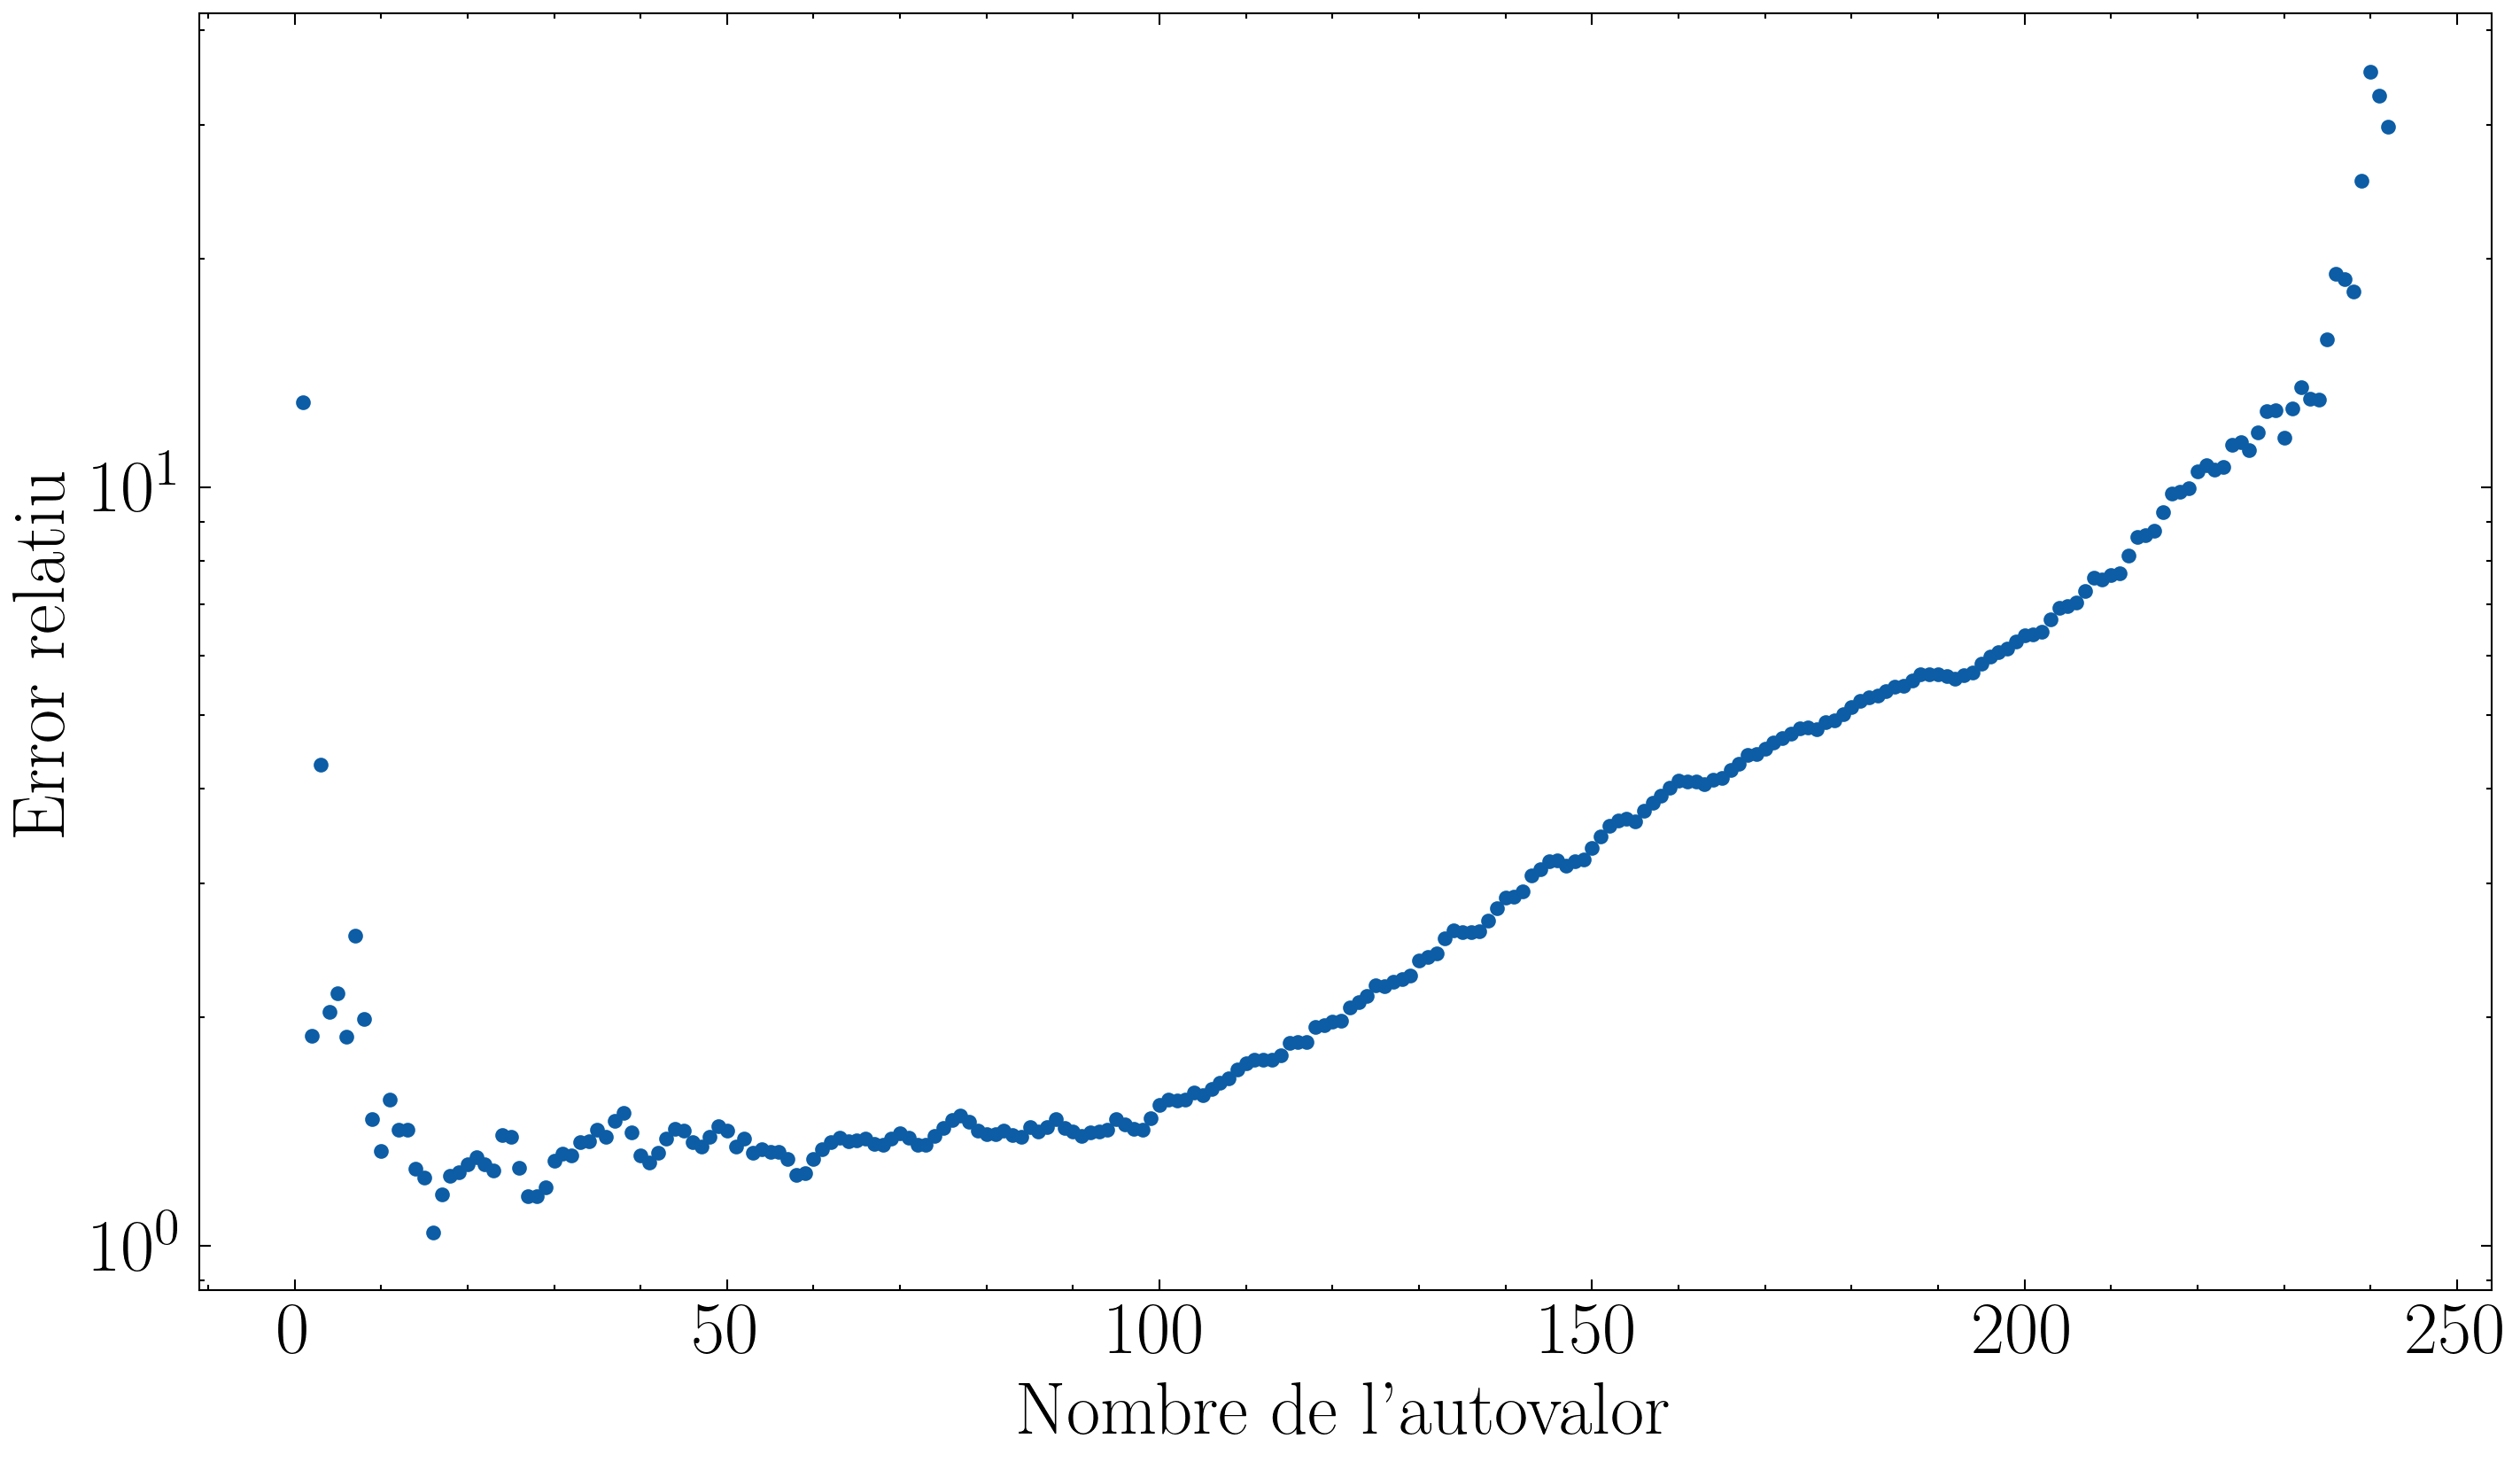

In [6]:
plt.figure(figsize=(10, 6))
plt.semilogy(n, relative_error, '.')
plt.xlabel("Nombre de l'autovalor")
plt.ylabel("Error relatiu")
plt.tight_layout()
plt.grid(False)
plt.plot()
plt.savefig('eigenvalue_error_real_values.png', dpi=300)

# Representació de les autofuncions

Maximum value is from wg; max_val = 5.9123274342131e-07
Maximum value is from ug; max_val = 5.912327640323946e-07
Maximum value is from wg; max_val = 0.02268933218479711
Maximum value is from wg; max_val = 2.409903968120503
kz = 0.01


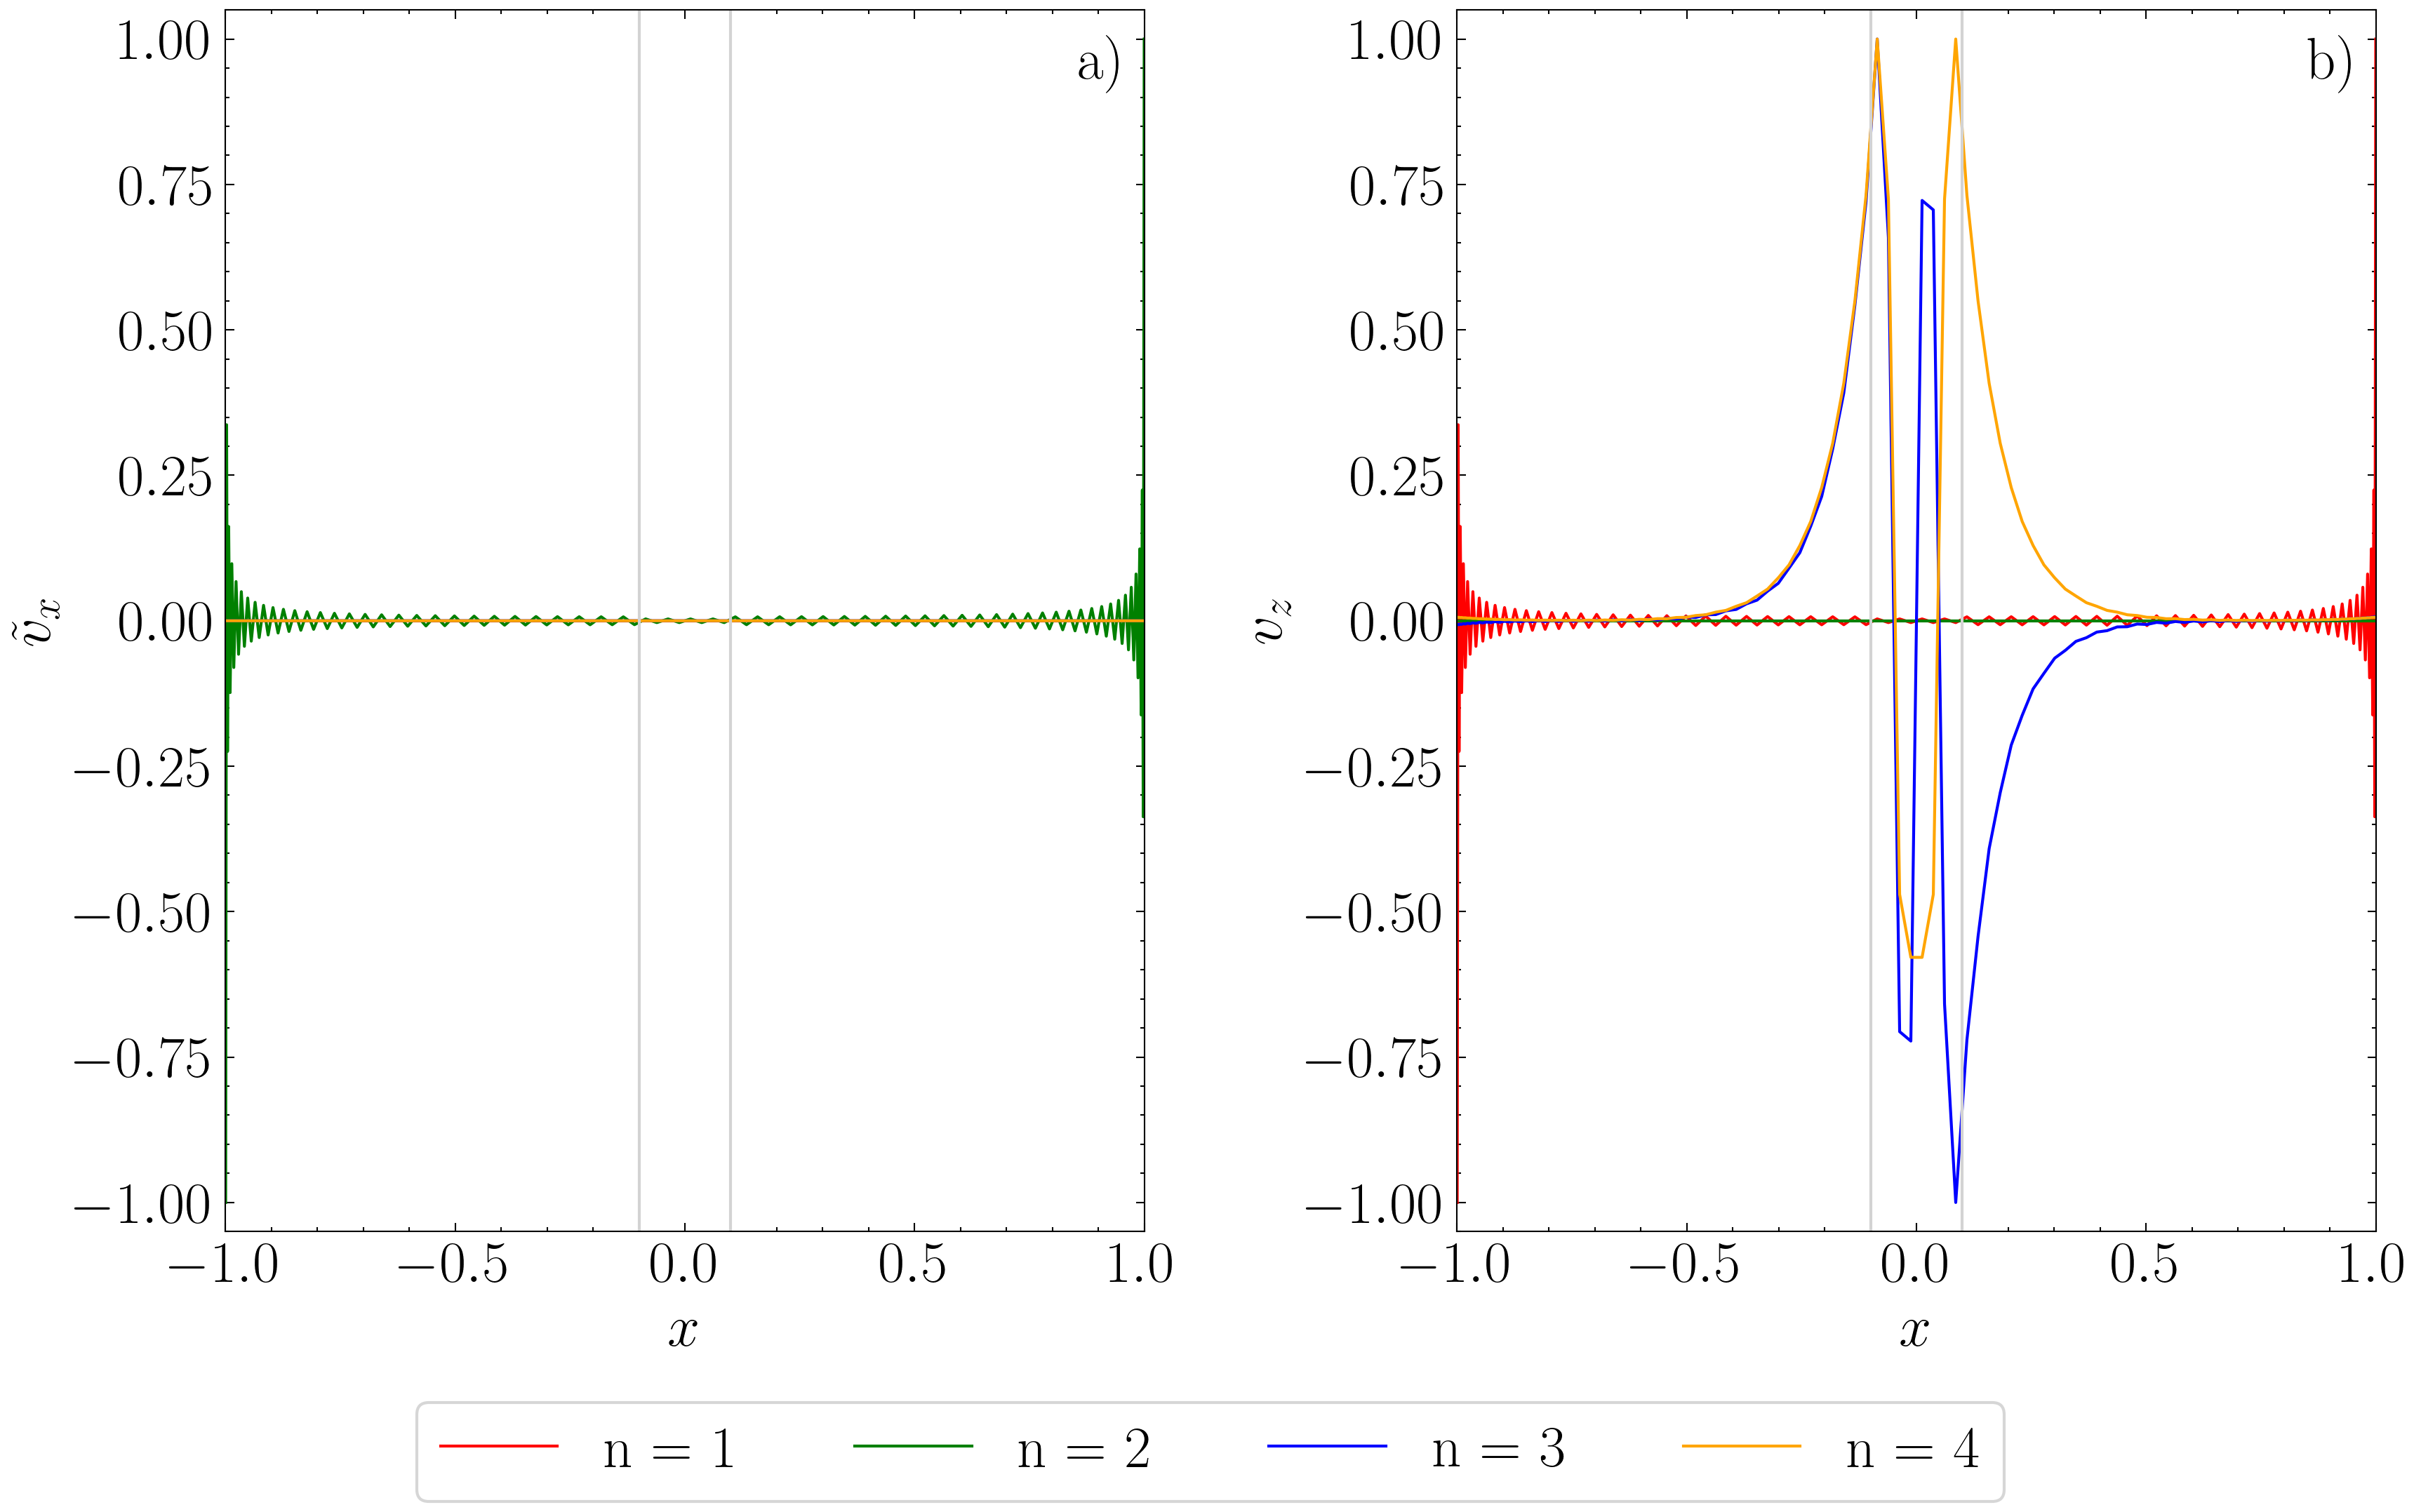

In [7]:
### Nombre de modes ###
N_max_mode = 4
N_min_mode = 0
N_modes = N_max_mode - N_min_mode

### Create a figure and a 1x2 grid of subplots ###
fig, axs = plt.subplots(1, 2, figsize=(12, 7))

### Define colors for the lines ###
colors = ['red', 'green', 'blue', 'orange', 'purple', 'brown', 'pink', 'gray']

# Example labels for the first 7 modes
mode_labels = [
    r"n = 1",
    r"n = 2",
    r"n = 3",
    r"n = 4",
    r"n = 5",
    r"n = 6",
    r"n = 7",
]

### Plot real part of v10x~ ###
x = dist.local_grid(xbasis)
for n, idx in enumerate(np.argsort(solver.eigenvalues)[N_min_mode:N_max_mode], start=1):
    solver.set_state(idx, solver.subsystems[0])
    ug = u['g'].real
    wg = w['g'].real

    # Definim bé el signe del màxim i després normalitzam
    if np.max(np.abs(ug)) > np.max(np.abs(wg)):
        
        #if n == 2:
        #    aux = -ug
        #else:
        aux = ug

    else:
        aux = wg

    index = np.argmax(np.abs(aux))
    max_val = aux[index]

    # Print the maximum value
    if np.max(np.abs(ug)) > np.max(np.abs(wg)):
        print("Maximum value is from ug; max_val =", max_val)
    else:
        print("Maximum value is from wg; max_val =", max_val)

    # Normalize both ug by the maximum value
    ug_normalized = ug / max_val

    axs[0].plot(x, ug_normalized, label=mode_labels[n-1], color=colors[n % len(colors) - 1])
axs[0].set_ylim(-1.05, 1.05)
axs[0].set_xlim(-1, 1)
axs[0].set_ylabel(r"$\tilde{v}_{x}$")
axs[0].set_xlabel(r"$x$")


x = dist.local_grid(xbasis)
for n, idx in enumerate(np.argsort(solver.eigenvalues)[N_min_mode:N_max_mode], start=1):
    solver.set_state(idx, solver.subsystems[0])
    ug = u['g'].real
    wg = w['g'].real

    # Definim bé el signe del màxim i després normalitzam
    if np.max(np.abs(ug)) > np.max(np.abs(wg)):
        
        aux = ug
    
    else:
        aux = wg

    index = np.argmax(np.abs(aux))
    max_val = aux[index]
    
    # Normalize wg by the maximum value
    wg_normalized = wg / max_val

    axs[1].plot(x, wg_normalized, label=mode_labels[n-1], color=colors[n % len(colors) - 1])
axs[1].set_ylim(-1.05, 1.05)
axs[1].set_xlim(-1, 1)
axs[1].set_ylabel(r"${v}_{z}$")
axs[1].set_xlabel(r"$x$")


# Add vertical lines to each subplot
for ax in axs.flat:
    ax.axvline(x=-0.1, color='lightgrey', linestyle='-', linewidth=1)
    ax.axvline(x=0.1, color='lightgrey', linestyle='-', linewidth=1)

# Add labels to the subplots
axs[0].text(0.98, 0.98, "a)", transform=axs[0].transAxes, fontsize=20, va='top', ha='right', fontweight='bold')
axs[1].text(0.98, 0.98, "b)", transform=axs[1].transAxes, fontsize=20, va='top', ha='right', fontweight='bold')

fig.legend(
    handles=axs[0].get_lines()[N_min_mode:N_max_mode],  # Use lines from the first subplot (they share labels/colors)
    labels=mode_labels[:N_max_mode],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.075),
    ncol=4,  # Adjust columns as needed
    frameon=True,
    fontsize=20,
    title_fontsize=20
)

print("kz =",kz)
plt.savefig("Autofuncions_reals_individuals_valors_reals.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()



In [4]:
# Valors realistes: cp2, cc2, vAp2, vAc2  137724550.89820358 27544910179.640717 3978873577.297384 795774715459.4768
#cp2 = 137724550.89820358
#cc2 = 27544910179.640717
#vAp2 = 3978873577.297384
#vAc2 = 795774715459.4768

print("Valors realistes:")
print("cp2 =",cp2)
print("cc2 =",cc2)
print("vAp2 = ",vAp2)
print("vAc2 =",vAc2)
print()

print("Relacions entre velocitats:")
print("cc2/cp2 = ",cc2/cp2)
print("vAc2/vAp2 = ",vAc2/vAp2)
print("vAp2/cp2 = ",vAp2/cp2)
print("vAc2/cc2 = ",vAc2/cc2)
print()
print("vAp2/cc2 = ",vAp2/cc2)
print("vAc2/cp2 = ",vAc2/cp2)
print("vAp2/vAc2 = ",vAp2/vAc2)
print("vAc2/vAp2 = ",vAc2/vAp2)

Valors realistes:
cp2 = 1.0
cc2 = 200.0
vAp2 =  28.890082061246225
vAc2 = 5778.016412249245

Relacions entre velocitats:
cc2/cp2 =  200.0
vAc2/vAp2 =  200.0
vAp2/cp2 =  28.890082061246225
vAc2/cc2 =  28.890082061246225

vAp2/cc2 =  0.14445041030623113
vAc2/cp2 =  5778.016412249245
vAp2/vAc2 =  0.005
vAc2/vAp2 =  200.0
